# Lab 2.3
## Carlos Gonzalez Mollinedo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paso 1. Carga y exploración del dataset inicial

In [2]:
df_tours_original = pd.read_csv('./data/tours_GT.csv')
df_tours = df_tours_original.copy()

In [9]:
print("AUDITORIA INICIAL DEL DATASET")
print("=" * 50)
print(f"Filas: {df_tours.shape[0]}") # Número de filas
print(f"Columnas: {df_tours.shape[1]}") # Número de columnas
print(f"Usos de memoria: {df_tours.memory_usage(deep=True).sum()/1024:.1F} B") # Uso de memoria
print(f"Usos de memoria: {df_tours.memory_usage(deep=True).sum()/1024:.1F} KB") # Uso de memoria
print(f"Usos de memoria: {df_tours.memory_usage(deep=True).sum()/1024**2:.1F} MB") # Uso de memoria
print("Tipos de datos")
print("=" * 50)
print(df_tours.dtypes)
print("=" * 50)
df_tours.head(2)

AUDITORIA INICIAL DEL DATASET
Filas: 6040
Columnas: 20
Usos de memoria: 4525.6 B
Usos de memoria: 4525.6 KB
Usos de memoria: 4.4 MB
Tipos de datos
id_reserva             str
fecha_reserva          str
destino                str
nombre_tour            str
tipo_tour              str
pax_adultos          int64
pax_ninos          float64
pais_origen            str
idioma_guia            str
precio_unitario    float64
ingreso_total      float64
duracion_horas     float64
calificacion       float64
metodo_pago            str
estado_reserva         str
id_guia                str
temporada              str
mes                  int64
anio                 int64
email_contacto         str
dtype: object


,id_reserva,fecha_reserva,destino,nombre_tour,tipo_tour,pax_adultos,pax_ninos,pais_origen,idioma_guia,precio_unitario,ingreso_total,duracion_horas,calificacion,metodo_pago,estado_reserva,id_guia,temporada,mes,anio,email_contacto
0,RES05530,2021-05-02,Playa del Carmen,Xcaret,Privado,2,1.0,España,Frances,1327.64,3319.10,5.0,2.7,Tarjeta credito,Confirmada,NaN,Media,5,2021,cliente417@outlook.com
1,RES00711,2021-08-15,Cancun,Laguna Nichupte,Grupal,18,1.0,Mexico,Español,883.19,16339.02,10.3,5.0,Transferencia,Completada,G014,Alta,8,2021,cliente732@hotmail.com


# Paso 2: Estadística descriptiva

In [31]:
print("Columnas numéricas")
print("=" * 50)
print(df_tours.describe().round(2))
print("Columnas categóricas")
print("=" * 50)
print(df_tours.describe(include=object))

Columnas numéricas
       pax_adultos  pax_ninos  precio_unitario  ingreso_total  duracion_horas  \
count      6040.00    5798.00          5862.00        6040.00         5736.00   
mean          8.55       2.05          1437.10       11539.33            7.02   
std           6.27       2.25          4294.00       26552.30            8.68   
min         -19.00       0.00           547.58      -23969.00            2.50   
25%           3.00       0.00           888.06        4447.04            4.50   
50%           7.00       1.00          1093.98        8088.30            6.50   
75%          14.00       3.00          1360.13       14608.11            8.50   
max          20.00      10.00         99999.00      500000.00          200.00   

       calificacion      mes     anio  
count       5591.00  6040.00  6040.00  
mean           4.27     6.14  2022.17  
std            3.00     3.54     0.95  
min           -1.00     1.00  2021.00  
25%            3.80     3.00  2021.00  
50%        

/var/folders/d2/f48j1whs76s686_wxd41_h7r0000gn/T/ipykernel_9618/1677724210.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_tours.describe(include=object))


# Paso 3. Mapa de valores faltantes

In [61]:
nulos = df_tours.isnull().sum()
nulos_porcentaje = (nulos / len(df_tours) * 100).round(2)
# Dataframe con el número de valores nulos por columna
reporte_nulos = pd.DataFrame({"total_nulos": nulos, "porcentaje": nulos_porcentaje}).query("total_nulos>0").sort_values("porcentaje", ascending=True)
print(reporte_nulos)
print(f"=" * 50)
total_nulos = nulos.sum()
print(f"Total de valores nulos: {total_nulos:,.0f}")



                 total_nulos  porcentaje
destino                   35        0.58
precio_unitario          178        2.95
idioma_guia              241        3.99
pax_ninos                242        4.01
id_guia                  302        5.00
pais_origen              304        5.03
duracion_horas           304        5.03
email_contacto           347        5.75
metodo_pago              363        6.01
calificacion             449        7.43
Total de valores nulos: 2,765


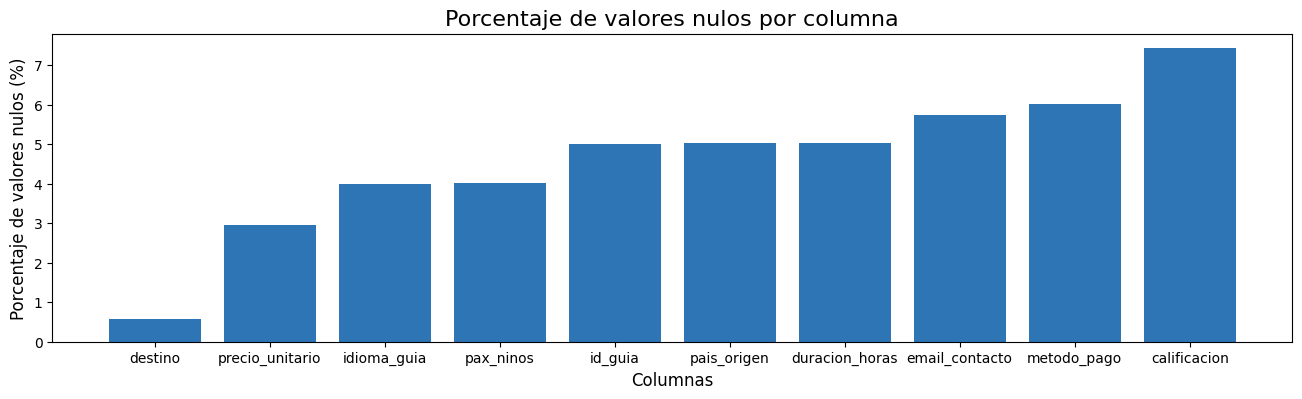

In [62]:
# Visualización
fig, ax = plt.subplots(figsize=(16, 4))
cols_con_nulos = reporte_nulos.index.tolist() # Recuperamos las columnas con nulos
ax.bar(cols_con_nulos, reporte_nulos["porcentaje"], color="#2e75b6")
ax.set_title("Porcentaje de valores nulos por columna", fontsize=16)
ax.set_xlabel("Columnas", fontsize=12)
ax.set_ylabel("Porcentaje de valores nulos (%)", fontsize=12)
plt.savefig("./reports/reporte_nulos.png", dpi=130)
plt.show()

# Paso 4: Valores negativos

In [69]:
cols_positivos =["pax_adultos", "pax_ninos", "precio_unitario", "ingreso_total", "duracion_horas", "calificacion"]
print("VALORES NEGATIVOS EN COLUMNAS NUMÉRICAS")
print("=" * 50)
for col in cols_positivos:
    negativos = (df_tours[col]<0).sum()
    ceros = (df_tours[col]==0).sum()
    if negativos > 0 or ceros > 0:
        print(f"{col:22s}: {negativos:3d} valores negativos | {ceros:3d} valores cero")

VALORES NEGATIVOS EN COLUMNAS NUMÉRICAS
pax_adultos           :  45 valores negativos |   0 valores cero
pax_ninos             :   0 valores negativos | 1810 valores cero
ingreso_total         :  45 valores negativos |   0 valores cero
calificacion          :   7 valores negativos |   0 valores cero


In [ ]:
# Ver las filas que son afectadas por paxs adultos negativos
print("Filas con pax_adultos negativos:")
print(df_tours[df_tours["pax_adultos"]<0][["id_reserva", "fecha_reserva", "pax_adultos", "destino"]].head(45))

Filas con pax_adultos negativos:
     id_reserva fecha_reserva  pax_adultos           destino
42     RES01194    2021-05-21           -3            Cancun
158    RES01173    2022-02-04          -11            Akumal
174    RES00811    2021-03-11           -5            Holbox
276    RES01872    2022-10-27          -15             Tulum
505    RES03847    2022-02-17           -2            Holbox
522    RES05730    2023-05-06          -14            Merida
712    RES03413    2022-06-05          -16            Merida
902    RES02026    2022-02-26          -17            Merida
1047   RES00417    2021-11-26          -19            Cancun
1100   RES01903    2023-02-18           -8            Akumal
1118   RES05849    2023-10-04           -1           Bacalar
1354   RES04248    2022-01-29           -1            Cancun
1433   RES04418    2023-12-24           -3             Tulum
1492   RES03797    2022-07-28          -14             Tulum
1755   RES01393    2022-09-29          -17          

# PASO 6 Inconsistencias en Categorías -> Técnica de normilización

In [8]:
cols_cat=["tipo_tour", "metodo_pago", "estado_reserva", "destino", "temporada", "idioma_guia"]
df=df_tours_original.copy()
print("-"*55)
print("VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS")
print("-"*55)
for col in cols_cat:
    unicos = df[col].dropna().unique()
    print(f"\n{col} ({len(unicos)} valores únicos):")
    print(f"{sorted(unicos)}")

print("\n CONTEO TIPO TOUR")
print(df["tipo_tour"].value_counts(dropna=False))
print("\n CONTEO TIPO TOUR DROPNA TRUE")
print(df["tipo_tour"].value_counts(dropna=True))
print("\n CONTEO METODO_PAGO")
print(df["metodo_pago"].value_counts(dropna=False))

-------------------------------------------------------
VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS
-------------------------------------------------------

tipo_tour (10 valores únicos):
['GRUPAL', 'Grupal', 'Gruupal', 'PRIVADO', 'Privad0', 'Privado', 'grupal', 'grupo', 'privad', 'privado']

metodo_pago (12 valores únicos):
['Crypto', 'EFECTIVO', 'Efctivo', 'Efectivo', 'Paypal', 'T. Credito', 'TARJETA CREDITO', 'Tarjeta credito', 'Tarjeta debito', 'Transferencia', 'efectivo', 'tarjeta credito']

estado_reserva (4 valores únicos):
['Cancelada', 'Completada', 'Confirmada', 'Pendiente']

destino (10 valores únicos):
['Akumal', 'Bacalar', 'Cancun', 'Chichen Itza', 'Cozumel', 'Holbox', 'Merida', 'Playa del Carmen', 'Tulum', 'Uxmal']

temporada (3 valores únicos):
['Alta', 'Baja', 'Media']

idioma_guia (6 valores únicos):
['Aleman', 'Español', 'Frances', 'Ingles', 'Italiano', 'Portugues']

 CONTEO TIPO TOUR
tipo_tour
Grupal     3891
Privado    2047
privado      17
Privad0      16
Gruupal      15

# Paso 7. Fechas con formatos inválidos —> Técnica de detección y estandarización de fechas

In [9]:
df["fechas_test"] = pd.to_datetime(df["fecha_reserva"], errors="coerce")
fechas_invalidas = df["fechas_test"].isnull().sum()
print(f"Fechas que no pudieron convertirse: {fechas_invalidas}")

Fechas que no pudieron convertirse: 60


In [10]:
mask_inv = df["fechas_test"].isna()
print(f"\n Ejemplos de fechas con formato incorrecto")
print(df[mask_inv]["fecha_reserva"].head(15).values)


 Ejemplos de fechas con formato incorrecto
<StringArray>
['2021/10/17', '19/12/2021', '2023/12/17', '04-29-2022', '05/02/2023',
 '08/10/2021', '11-23-2021', '2021/06/08', '01-12-2024', '04-23-2022',
 '30/03/2022', '2023/06/08', '09-04-2023', '01-19-2022', '03-02-2023']
Length: 15, dtype: str


In [11]:
import re
patrones = {
    "YYYY-MM-DD": r"^\d{4}-\d{2}-\d{2}$",
    "DD/MM/YYYY": r"^\d{2}/\d{2}/\d{4}$",
    "MM-DD-YYYY": r"^\d{2}-\d{2}-\d{4}$",
    "DD-MM-YYYY": r"^\d{2}-\d{2}-\d{4}$",
    }
for nombre, patron in patrones.items():
    n = df["fecha_reserva"].str.match(patron, na=False).sum()
    print(f"{nombre:15s}: {n:5d} registros")

YYYY-MM-DD     :  5980 registros
DD/MM/YYYY     :    20 registros
MM-DD-YYYY     :    20 registros
DD-MM-YYYY     :    20 registros


# Paso 8. Correos electrónicos con formatos inválidos —> Técnica de validación con expresiones regulares

In [ ]:
patron_email=r"^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$"